# Macro Regime Asset Allocation

#### **Objective:**
Develop and evaluate a rule-based asset allocation strategy that adjusts portfolio weights according to U.S. macroeconomic conditions. The goal is to determine whether a macro-driven allocation can improve risk-adjusted performance relative to passive investing.

#### **Research Questions:**
**1.** Can publicly available macroeconomic indicators identify meaningful business-cycle regimes?
**2.** Do different macro regimes favor different asset classes?
**3.** Does a static macro allocation improve risk-adjusted returns compared with passive investing?

#### **Strategy**
**1.** Static macro regime allocation
**2.** Walk-forward regime allocation, re-estimated on an expanding and a rolling window

#### **Methodology**
Download macroeconomic data
&nbsp;&nbsp;&nbsp;&nbsp;↓
Classify macro regime
&nbsp;&nbsp;&nbsp;&nbsp;↓
Assign portfolio weights
&nbsp;&nbsp;&nbsp;&nbsp;↓
Download ETF prices
&nbsp;&nbsp;&nbsp;&nbsp;↓
Backtest portfolio
&nbsp;&nbsp;&nbsp;&nbsp;↓
Evaluate performance

#### **Asset Universe**
| Asset Class          | ETF | Purpose                           |
| --------------------- | --- | ---------------------------------- |
| U.S. Equity            | SPY | Broad market exposure              |
| Growth Equity          | QQQ | Technology and growth exposure     |
| Long-Term Treasuries   | TLT | Defensive asset during recessions  |
| Gold                   | GLD | Inflation hedge                    |
| Energy                 | XLE | Commodity/inflation exposure       |
| Cash                   | BIL | Short-term Treasury bills          |

#### **Macroeconomic Indicators**
This strategy classifies the economy using publicly available macroeconomic data from FRED:

- Consumer Price Index (Inflation)
- Unemployment Rate
- Industrial Production
- Federal Funds Rate
- NBER Recession Indicator

These variables capture both inflationary and growth conditions in the U.S. economy.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import yfinance as yf
from pandas_datareader import data as web
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

In [2]:
# Settings

START_DATE = "2000-01-01"
END_DATE = None
ASSETS = ["SPY", "QQQ", "TLT", "GLD", "XLE", "BIL"]

# Download ETF price data

prices = yf.download(
    ASSETS,
    start=START_DATE,
    auto_adjust=True,
    progress=False
)["Close"]

agg_prices = yf.download("AGG", start=START_DATE, auto_adjust=True, progress=False)["Close"]

# Download macroeconomic data from FRED

fred_series = {
    "CPI": "CPIAUCSL",
    "Unemployment": "UNRATE",
    "Industrial Production": "INDPRO",
    "Fed Funds": "FEDFUNDS",
    "Recession": "USREC",
    "RFR": "TB3MS"
}

series_list = []
for name, ticker in fred_series.items():
    df = web.DataReader(ticker, "fred", START_DATE, END_DATE)
    df = df.rename(columns={ticker: name})
    series_list.append(df)

macro = pd.concat(series_list, axis=1)

In [3]:
# Regime Classification
#
# Regimes sit on a 2x2 grid of trailing 12-month inflation vs. industrial
# production growth. The regime label is shifted forward one month so each
# month's allocation only uses information available at the time.

macro["inflation"] = macro["CPI"].pct_change(12) * 100
macro["growth"] = macro["Industrial Production"].pct_change(12) * 100

INFLATION_THRESHOLD = 2.0
GROWTH_THRESHOLD = 2.0

macro["inflation_state"] = np.where(macro["inflation"] >= INFLATION_THRESHOLD, 1, -1)
macro["growth_state"] = np.where(macro["growth"] >= GROWTH_THRESHOLD, 1, -1)

def classify_regime(row):
    if row["inflation_state"] > 0 and row["growth_state"] > 0:
        return "Inflationary Expansion"
    elif row["inflation_state"] > 0 and row["growth_state"] < 0:
        return "Stagflation"
    elif row["inflation_state"] < 0 and row["growth_state"] > 0:
        return "Goldilocks"
    elif row["inflation_state"] < 0 and row["growth_state"] < 0:
        return "Slowdown"

macro["regime"] = macro.apply(classify_regime, axis=1).shift(1)

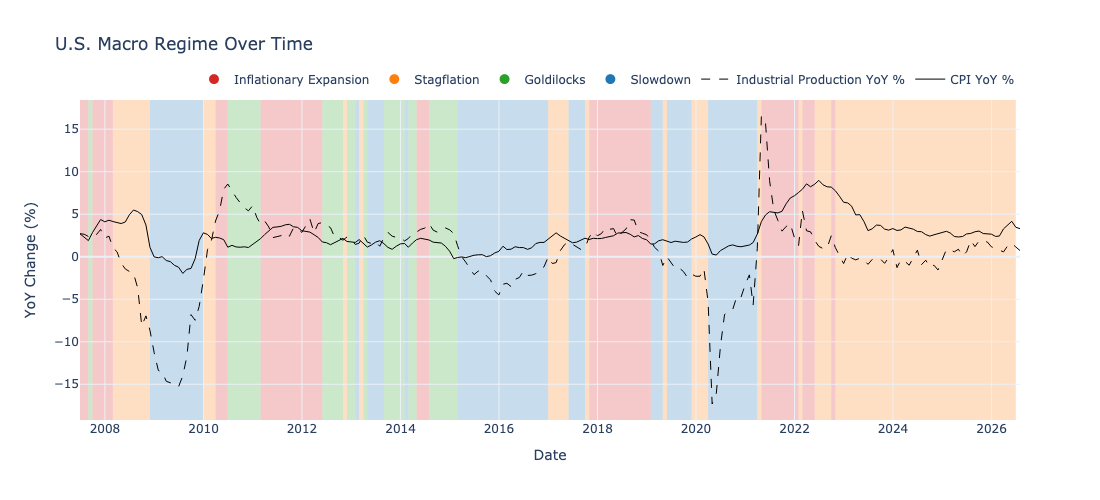

In [ ]:
import plotly.graph_objects as go

REGIME_COLORS = {
    "Inflationary Expansion": "#d62728",  # red
    "Stagflation": "#ff7f0e",             # orange
    "Goldilocks": "#2ca02c",              # green
    "Slowdown": "#1f77b4",                # blue
}

regime_series = macro["regime"].shift(-1).dropna()

# Collapse into contiguous same-regime segments so each vrect spans
# a full regime period rather than drawing one rect per month
segments = []
start_date = regime_series.index[0]
current_regime = regime_series.iloc[0]

for date, regime in regime_series.items():
    if regime != current_regime:
        segments.append((start_date, date, current_regime))
        start_date = date
        current_regime = regime
segments.append((start_date, regime_series.index[-1], current_regime))

fig = go.Figure()

for seg_start, seg_end, regime in segments:
    fig.add_vrect(
        x0=seg_start, x1=seg_end,
        fillcolor=REGIME_COLORS.get(regime, "gray"),
        opacity=0.25, line_width=0, layer="below"
    )

# vrects don't generate legend entries on their own, so add invisible
# markers just to populate the legend
for regime, color in REGIME_COLORS.items():
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode="markers",
        marker=dict(size=10, color=color), name=regime
    ))

# Overlay something the band gives context to — industrial production
# growth works well since it's one of your two classifying inputs
fig.add_trace(go.Scatter(
    x=macro.index, y=macro["growth"], mode="lines",
    name="Industrial Production YoY %", line=dict(dash="dash", color="black", width=1)
))
fig.add_trace(go.Scatter(
    x=macro.index, y=macro["inflation"], mode="lines",
    name="CPI YoY %", line=dict(color="black", width=1)
))

fig.update_layout(
    title="U.S. Macro Regime Over Time",
    xaxis_title="Date", yaxis_title="YoY Change (%)",
    template="plotly_white", width=1100, height=500,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.update_xaxes(
    type="date",
    range=[macro.index.min(), macro.index.max()]
)
fig.show(renderer="png")

## Helper Functions

In [5]:
def performance_summary(returns, rf_returns, name):
    """Annualized volatility, Sharpe ratio, max drawdown, and total return for a return series."""
    returns = returns.dropna()

    cumulative_return = (1 + returns).prod()

    rf = rf_returns.loc[returns.index]
    excess = returns - rf
    vol = returns.std() * np.sqrt(12)
    sharpe = (excess.mean() * 12) / vol if vol != 0 else np.nan

    equity = (1 + returns).cumprod()
    drawdown = equity / equity.cummax() - 1
    max_drawdown = drawdown.min()

    return {
        "Strategy": name,
        "Volatility": vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_drawdown,
        "Total Return": cumulative_return - 1
    }


def geo_annualize(r):
    """Geometric annualized return from a series of monthly returns."""
    r = r.dropna()
    growth = (1 + r).prod()
    n = len(r)
    return growth ** (12 / n) - 1 if n > 0 else np.nan


def drawdown_series(cumulative_return):
    """Peak-to-trough drawdown series from a cumulative return series."""
    equity = 1 + cumulative_return
    return equity / equity.cummax() - 1


def compute_regime_weights(hist_data, assets, min_obs=12, floor=0.05):
    """Sharpe-based regime weights estimated from historical data up to a cutoff date."""
    counts = hist_data.groupby("regime")[assets[0]].count()
    valid_regimes = counts[counts >= min_obs].index

    regime_returns = hist_data.groupby("regime")[assets + ["rf_monthly"]].mean()
    regime_annualized = (1 + regime_returns) ** 12 - 1
    regime_vol = hist_data.groupby("regime")[assets].std() * np.sqrt(12)

    sharpe = (
        regime_annualized[assets]
        .sub(regime_annualized["rf_monthly"], axis=0)
        .div(regime_vol)
    )
    sharpe = sharpe.loc[sharpe.index.isin(valid_regimes)]

    positive = sharpe.clip(lower=0)
    weights = positive.div(positive.sum(axis=1), axis=0)

    weights["BIL"] = floor
    other_assets = [a for a in assets if a != "BIL"]
    weights[other_assets] = weights[other_assets].div(
        weights[other_assets].sum(axis=1), axis=0
    ) * (1 - floor)

    return weights.fillna(0)


def get_weights_for_date(date, weights_by_date):
    """Look up the most recent re-estimated weight table available as of a given date."""
    applicable = [d for d in weights_by_date if d <= date]
    if not applicable:
        raise ValueError(f"No re-estimation cutoff available before {date}")
    cutoff = max(applicable)
    return weights_by_date[cutoff]

# Version I — Theoretical Static Weights

In [6]:
# Assign static theoretical weights by regime

REGIME_WEIGHTS = {
    "Goldilocks": {"SPY": 0.30, "QQQ": 0.45, "TLT": 0.10, "GLD": 0.05, "XLE": 0.05, "BIL": 0.05},
    "Inflationary Expansion": {"SPY": 0.30, "QQQ": 0.15, "TLT": 0.05, "GLD": 0.15, "XLE": 0.30, "BIL": 0.05},
    "Stagflation": {"SPY": 0.15, "QQQ": 0.00, "TLT": 0.05, "GLD": 0.40, "XLE": 0.30, "BIL": 0.10},
    "Slowdown": {"SPY": 0.20, "QQQ": 0.00, "TLT": 0.50, "GLD": 0.10, "XLE": 0.00, "BIL": 0.20},
}

weight_cols = list(REGIME_WEIGHTS["Goldilocks"].keys())
for col in weight_cols:
    macro[f"{col}_weight"] = 0.0

for regime, weights in REGIME_WEIGHTS.items():
    mask = macro["regime"] == regime
    for asset, weight in weights.items():
        macro.loc[mask, f"{asset}_weight"] = weight

# Align macro data to month-end and compute ETF monthly returns

macro.index = macro.index.to_period("M").to_timestamp("M")
monthly_returns = prices.resample("ME").last().pct_change()

portfolio_return = sum(monthly_returns[asset] * macro[f"{asset}_weight"] for asset in ASSETS)
agg_returns = agg_prices.resample("ME").last().pct_change()
agg_returns = agg_returns.squeeze()
sixty_forty_return = 0.6 * monthly_returns["SPY"] + 0.4 * agg_returns

start = max(monthly_returns["SPY"].first_valid_index(), portfolio_return.first_valid_index())
monthly_returns = monthly_returns.loc[start:]
portfolio_return = portfolio_return.loc[start:]
sixty_forty_return = sixty_forty_return.loc[start:]
macro = macro.loc[start:]

macro["strategy_return"] = (1 + portfolio_return).cumprod() - 1
macro["benchmark_spy"] = (1 + monthly_returns["SPY"].fillna(0)).cumprod() - 1
macro["benchmark_sixty_forty"] = (1 + sixty_forty_return.fillna(0)).cumprod() -1



Performance Summary — Version I (Static Weights):
                  Strategy  Volatility  Sharpe  Max Drawdown  Total Return
0  Macro Strategy (Static)      0.1200  0.4630       -0.2634        2.2702
1           SPY Buy & Hold      0.1553  0.6544       -0.5078        6.2259
2            60/40 SPY/AGG      0.0994  0.6823       -0.3232        3.3441

Annualized Returns by Regime — Version I:
                        Strategy Return  SPY_Return  60/40 Return
regime                                                           
Goldilocks                     0.247904    0.296981      0.189718
Inflationary Expansion         0.060557   -0.011492      0.007974
Slowdown                       0.022861    0.234652      0.150047
Stagflation                    0.033573    0.025745      0.029850


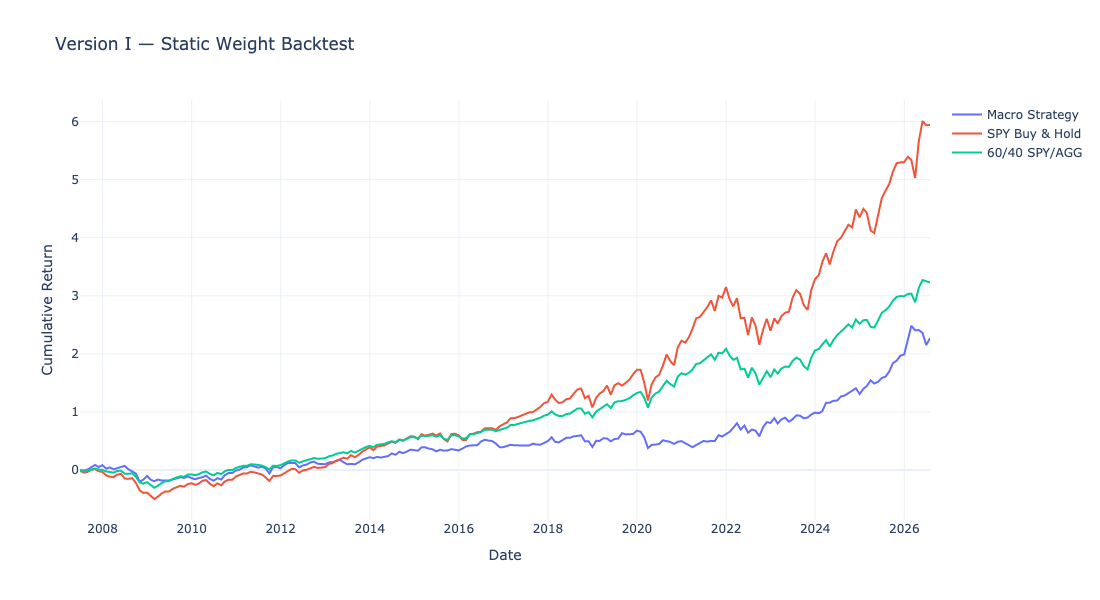

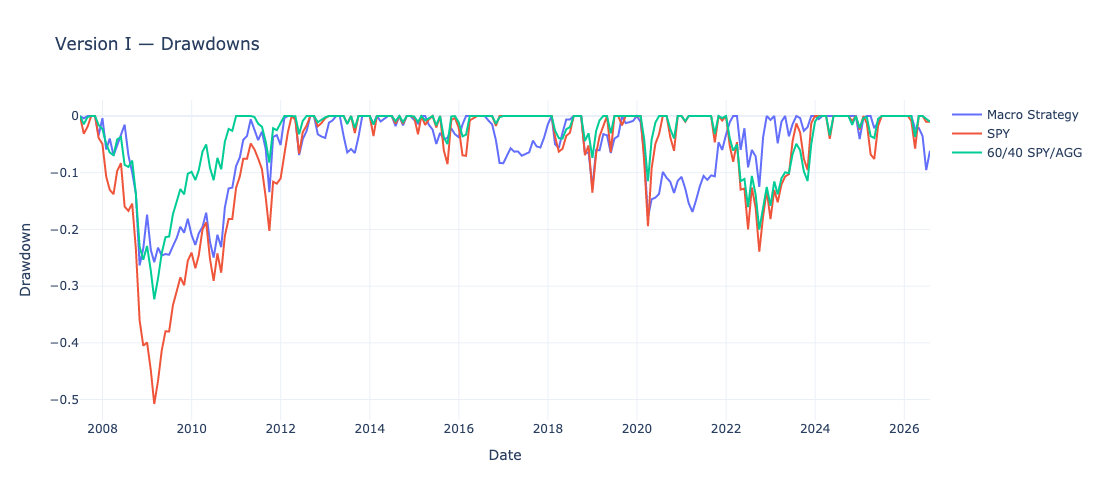

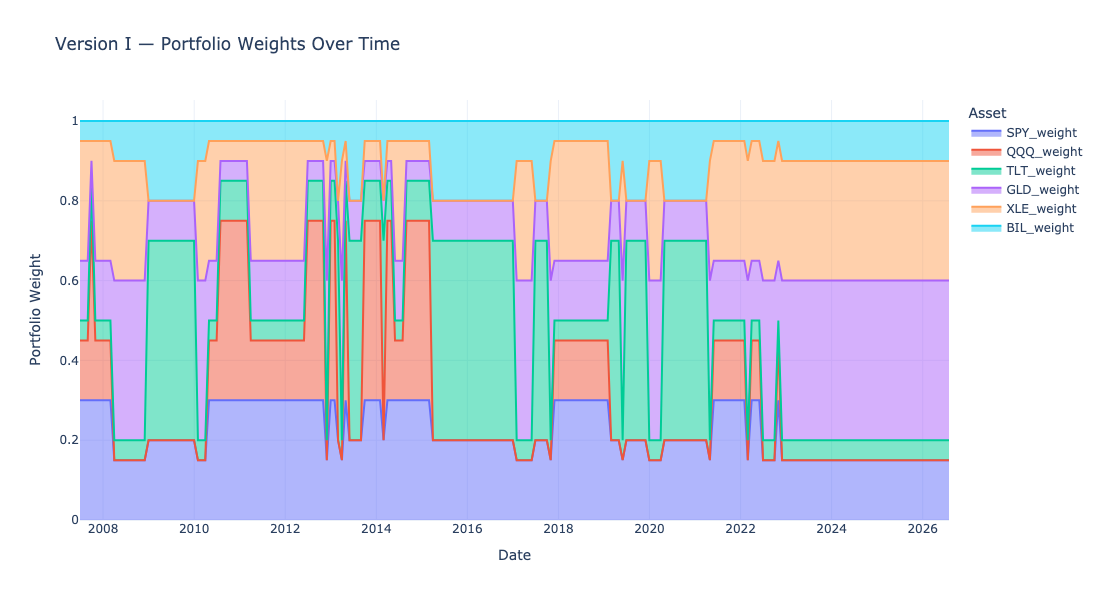

In [7]:
perf_v1 = pd.DataFrame([
    performance_summary(portfolio_return, monthly_returns["BIL"], "Macro Strategy (Static)"),
    performance_summary(monthly_returns["SPY"], monthly_returns["BIL"], "SPY Buy & Hold"),
    performance_summary(sixty_forty_return, monthly_returns["BIL"], "60/40 SPY/AGG"),
])
print("\nPerformance Summary — Version I (Static Weights):")
print(perf_v1.round(4))

regime_returns_v1 = pd.DataFrame(index=macro.index)
regime_returns_v1["Strategy Return"] = portfolio_return
regime_returns_v1["SPY_Return"] = monthly_returns["SPY"]
regime_returns_v1["60/40 Return"] = sixty_forty_return
regime_returns_v1["regime"] = macro["regime"]

regime_perf_v1 = regime_returns_v1.groupby("regime")[["Strategy Return", "SPY_Return", "60/40 Return"]].apply(
    lambda g: g.apply(geo_annualize)
)
print("\nAnnualized Returns by Regime — Version I:")
print(regime_perf_v1)

# Equity curve

fig = go.Figure()
fig.add_trace(go.Scatter(x=macro.index, y=macro["strategy_return"], mode="lines", name="Macro Strategy"))
fig.add_trace(go.Scatter(x=macro.index, y=macro["benchmark_spy"], mode="lines", name="SPY Buy & Hold"))
fig.add_trace(go.Scatter(x=macro.index, y=(1 + sixty_forty_return.fillna(0)).cumprod() - 1, mode="lines", name="60/40 SPY/AGG"))
fig.update_layout(
    title="Version I — Static Weight Backtest",
    xaxis_title="Date", yaxis_title="Cumulative Return",
    template="plotly_white", width=1100, height=600
)
fig.show(renderer="png")

# Drawdowns

dd_strategy_v1 = drawdown_series(macro["strategy_return"])
dd_spy_v1 = drawdown_series(macro["benchmark_spy"])
dd_sixty_forty_v1 = drawdown_series(macro["benchmark_sixty_forty"])

fig = go.Figure()
fig.add_trace(go.Scatter(x=dd_strategy_v1.index, y=dd_strategy_v1, mode="lines", name="Macro Strategy"))
fig.add_trace(go.Scatter(x=dd_spy_v1.index, y=dd_spy_v1, mode="lines", name="SPY"))
fig.add_trace(go.Scatter(x=dd_sixty_forty_v1.index, y=dd_sixty_forty_v1, mode="lines", name="60/40 SPY/AGG"))
fig.update_layout(
    title="Version I — Drawdowns",
    xaxis_title="Date", yaxis_title="Drawdown",
    template="plotly_white", width=1100, height=500
)
fig.show(renderer="png")

# Portfolio weights over time

weights_cols = [f"{asset}_weight" for asset in ASSETS]
weights_long_v1 = macro[weights_cols].reset_index(names="Date").melt(
    id_vars="Date", var_name="Asset", value_name="Weight"
)
fig = px.area(weights_long_v1, x="Date", y="Weight", color="Asset", title="Version I — Portfolio Weights Over Time")
fig.update_layout(template="plotly_white", width=1100, height=600, yaxis_title="Portfolio Weight")
fig.show(renderer="png")

## Exploratory Diagnostics

Sanity checks on the regime classification before building the walk-forward backtests.

regime
Stagflation               76
Slowdown                  66
Inflationary Expansion    57
Goldilocks                31
Name: count, dtype: int64

                        inflation    growth
regime                                     
Goldilocks               1.415551  3.393591
Inflationary Expansion   3.637070  3.559291
Slowdown                 0.922473 -4.094538
Stagflation              3.579687  0.125683

Annualized ETF Returns by Regime:
Ticker                       SPY       QQQ       TLT       GLD       XLE  \
regime                                                                     
Goldilocks              0.296981  0.312138  0.041528  0.003502  0.291378   
Inflationary Expansion -0.011492  0.002845  0.104582  0.104568  0.108027   
Slowdown                0.234652  0.322241 -0.062340  0.065593  0.191554   
Stagflation             0.025745  0.095475  0.052069  0.153450 -0.142566   

Ticker                       BIL  
regime                            
Goldilocks             -

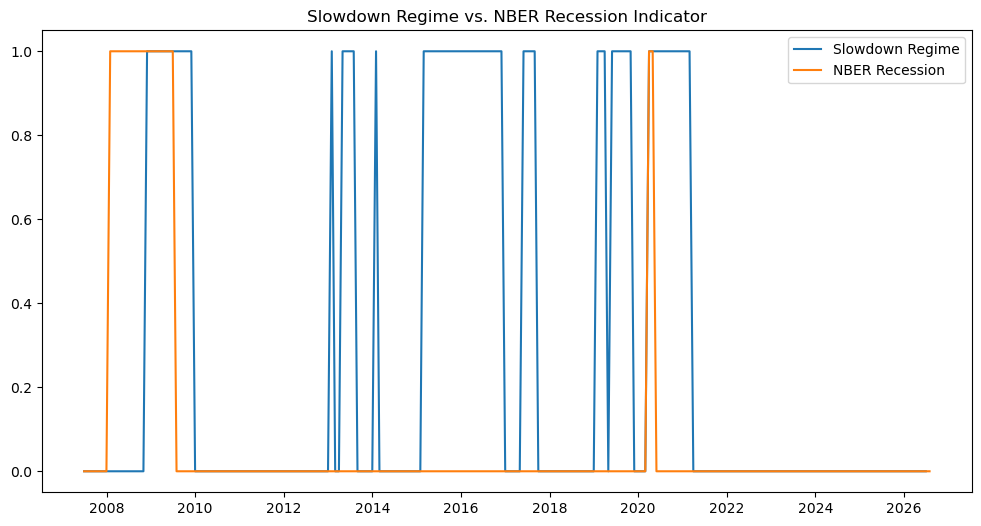

In [8]:
# Regime frequency and macro characteristics

print(macro["regime"].value_counts())
print()
print(macro.groupby("regime")[["inflation", "growth"]].mean())

monthly_returns["regime"] = macro["regime"]
etf_regime_geo = monthly_returns.groupby("regime")[ASSETS].apply(lambda g: g.apply(geo_annualize))
print("\nAnnualized ETF Returns by Regime:")
print(etf_regime_geo)

# Does the Slowdown regime track NBER recessions?

slowdown_indicator = (macro["regime"] == "Slowdown").astype(int)
slowdown_indicator = slowdown_indicator.shift(-1)  # undo the classification lag

plt.figure(figsize=(12, 6))
plt.plot(macro.index, slowdown_indicator, label="Slowdown Regime")
plt.plot(macro.index, macro["Recession"], label="NBER Recession")
plt.legend()
plt.title("Slowdown Regime vs. NBER Recession Indicator")
plt.show()

# Build Master Dataset for Walk-Forward Backtests

In [9]:
# ETF monthly returns + regime label + monthly risk-free rate, used by
# Versions II and III below

regime_data = monthly_returns.copy()
regime_data["rf_monthly"] = macro["RFR"] / 100 / 12  # annualized T-bill % -> monthly decimal rate

# Version II — Expanding Window Walk-Forward

At each annual cutoff, regime weights are estimated from all data up to that point, then held fixed until the next re-estimation date.

In [10]:
BURN_IN_MONTHS = 60

first_all_assets_valid = prices[ASSETS].apply(lambda s: s.first_valid_index()).max()
first_eval_date = max(regime_data.index[BURN_IN_MONTHS], first_all_assets_valid)
eval_period = regime_data.loc[first_eval_date:]

REESTIMATION_DATES = pd.date_range(first_eval_date, regime_data.index.max(), freq="YS")
if REESTIMATION_DATES[0] != first_eval_date:
    REESTIMATION_DATES = pd.DatetimeIndex([first_eval_date]).append(REESTIMATION_DATES)

wf_weights_by_date = {}
prev_weights = None
for cutoff in REESTIMATION_DATES:
    hist = regime_data.loc[:cutoff - pd.Timedelta(days=1)]
    if len(hist) < 36:
        continue
    w = compute_regime_weights(hist, ASSETS)
    wf_weights_by_date[cutoff] = w
    prev_weights = w

test_weights_wf = pd.DataFrame(index=eval_period.index, columns=ASSETS, dtype=float)
for date in eval_period.index:
    regime = eval_period.loc[date, "regime"]
    w_table = get_weights_for_date(date, wf_weights_by_date)
    if pd.notna(regime) and regime in w_table.index:
        test_weights_wf.loc[date] = w_table.loc[regime]
    else:
        test_weights_wf.loc[date] = prev_weights.mean()

test_returns_wf = eval_period[ASSETS].copy()
wf_portfolio_return = (test_returns_wf * test_weights_wf).sum(axis=1)
wf_cumulative_return = (1 + wf_portfolio_return).cumprod() - 1

spy_eval_returns = eval_period["SPY"].copy()
spy_eval_returns.iloc[0] = 0
spy_cumulative_return_wf = (1 + spy_eval_returns).cumprod() - 1

sixty_forty_eval_return = 0.6 * eval_period["SPY"] + 0.4 * agg_returns.squeeze().loc[eval_period.index]
sixty_forty_cumulative_return = (1 + sixty_forty_eval_return.fillna(0)).cumprod() - 1


Performance Summary — Version II (Expanding Window):
                            Strategy  Volatility  Sharpe  Max Drawdown  \
0  Macro Strategy (Expanding Window)      0.1222  0.8248       -0.3010   
1                     SPY Buy & Hold      0.1397  0.9624       -0.2393   
2                      60/40 SPY/AGG      0.0918  0.9119       -0.2005   

   Total Return  
0        3.6918  
1        6.2868  
2        2.8537  

Annualized Returns by Regime — Version II:
                        Strategy Return  SPY_Return  60/40 Return
regime                                                           
Goldilocks                     0.097483    0.196438      0.150894
Inflationary Expansion        -0.033584    0.085910      0.043940
Slowdown                       0.202258    0.230385      0.140383
Stagflation                    0.120275    0.095854      0.072437


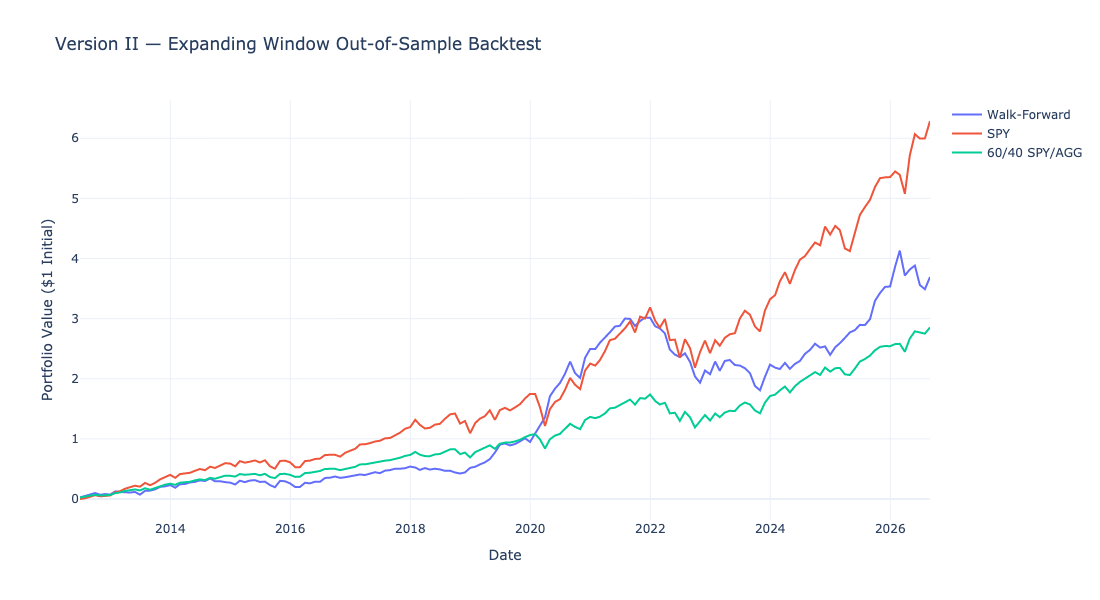

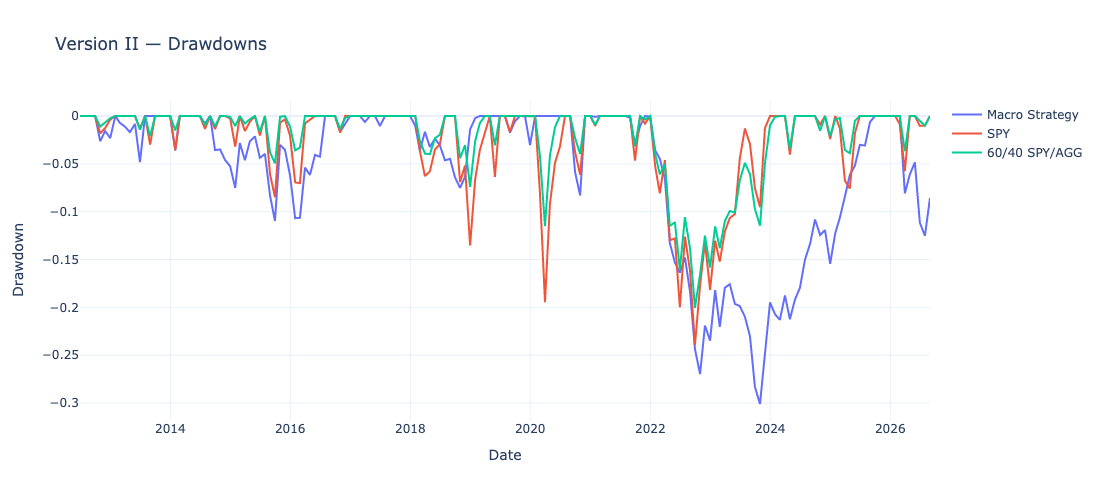

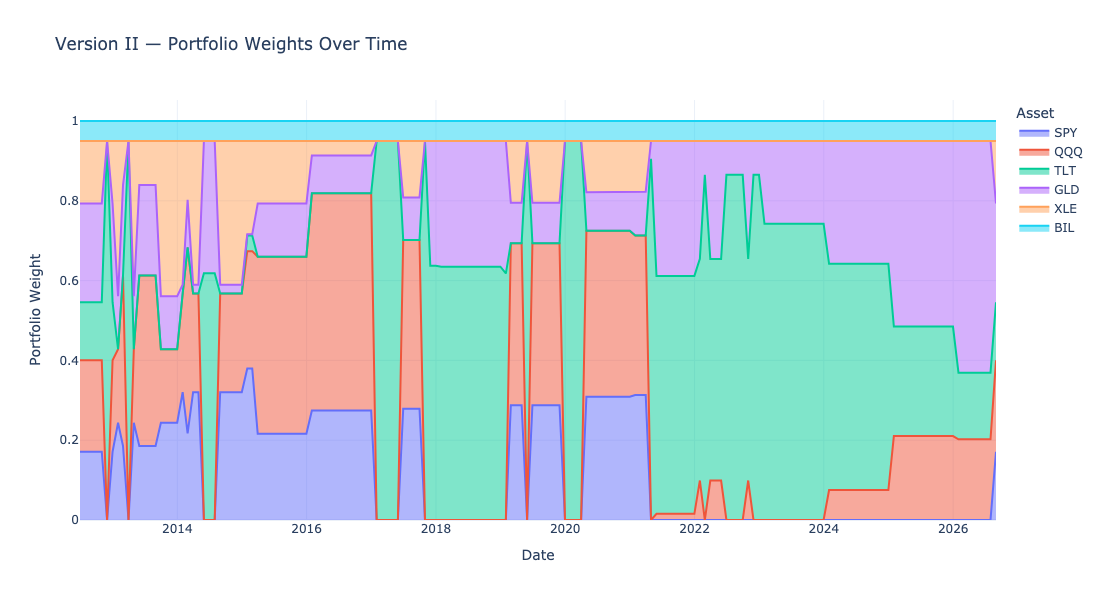

In [11]:
perf_v2 = pd.DataFrame([
    performance_summary(wf_portfolio_return, monthly_returns["BIL"], "Macro Strategy (Expanding Window)"),
    performance_summary(spy_eval_returns, monthly_returns["BIL"], "SPY Buy & Hold"),
    performance_summary(sixty_forty_eval_return, monthly_returns["BIL"], "60/40 SPY/AGG")
])
print("\nPerformance Summary — Version II (Expanding Window):")
print(perf_v2.round(4))

regime_returns_v2 = pd.DataFrame(index=wf_portfolio_return.index)
regime_returns_v2["Strategy Return"] = wf_portfolio_return
regime_returns_v2["SPY_Return"] = spy_eval_returns
regime_returns_v2["60/40 Return"] = sixty_forty_eval_return
regime_returns_v2["regime"] = macro["regime"]

regime_perf_v2 = regime_returns_v2.groupby("regime")[["Strategy Return", "SPY_Return", "60/40 Return"]].apply(
    lambda g: g.apply(geo_annualize)
)
print("\nAnnualized Returns by Regime — Version II:")
print(regime_perf_v2)

fig = go.Figure()
fig.add_trace(go.Scatter(x=wf_cumulative_return.index, y=wf_cumulative_return, mode="lines", name="Walk-Forward"))
fig.add_trace(go.Scatter(x=spy_cumulative_return_wf.index, y=spy_cumulative_return_wf, mode="lines", name="SPY"))
fig.add_trace(go.Scatter(x=sixty_forty_cumulative_return.index, y=sixty_forty_cumulative_return, mode="lines", name="60/40 SPY/AGG"))

fig.update_layout(
    title="Version II — Expanding Window Out-of-Sample Backtest",
    xaxis_title="Date", yaxis_title="Portfolio Value ($1 Initial)",
    template="plotly_white", width=1100, height=600
)
fig.show(renderer="png")

dd_strategy_v2 = drawdown_series(wf_cumulative_return)
dd_spy_v2 = drawdown_series(spy_cumulative_return_wf)
dd_sixty_forty_v2 = drawdown_series(sixty_forty_cumulative_return)

fig = go.Figure()
fig.add_trace(go.Scatter(x=dd_strategy_v2.index, y=dd_strategy_v2, mode="lines", name="Macro Strategy"))
fig.add_trace(go.Scatter(x=dd_spy_v2.index, y=dd_spy_v2, mode="lines", name="SPY"))
fig.add_trace(go.Scatter(x=dd_sixty_forty_v2.index, y=dd_sixty_forty_v2, mode="lines", name="60/40 SPY/AGG"))
fig.update_layout(
    title="Version II — Drawdowns",
    xaxis_title="Date", yaxis_title="Drawdown",
    template="plotly_white", width=1100, height=500
)
fig.show(renderer="png")

weights_long_v2 = test_weights_wf.reset_index(names="Date").melt(id_vars="Date", var_name="Asset", value_name="Weight")
fig = px.area(weights_long_v2, x="Date", y="Weight", color="Asset", title="Version II — Portfolio Weights Over Time")
fig.update_layout(template="plotly_white", width=1100, height=600, yaxis_title="Portfolio Weight")
fig.show(renderer="png")

In [12]:
fallback_count_v2 = sum(
    1 for date in eval_period.index
    if not (
        pd.notna(eval_period.loc[date, "regime"]) and
        eval_period.loc[date, "regime"] in get_weights_for_date(date, wf_weights_by_date).index
    )
)
print(f"{fallback_count_v2} of {len(eval_period)} dates used the fallback (Version II)")

7 of 171 dates used the fallback (Version II)


# Version III — Rolling Window Walk-Forward

Same as Version II, but each re-estimation only looks back a fixed window (`ROLLING_WINDOW_YEARS`) instead of all history, so weights can adapt to more recent regime dynamics.

In [13]:
ROLLING_WINDOW_YEARS = 10

wf_weights_by_date_rolling = {}
prev_weights = None
for cutoff in REESTIMATION_DATES:
    window_start = cutoff - pd.DateOffset(years=ROLLING_WINDOW_YEARS)
    hist = regime_data.loc[window_start:cutoff - pd.Timedelta(days=1)]
    if len(hist) < 36:
        continue
    w = compute_regime_weights(hist, ASSETS)
    wf_weights_by_date_rolling[cutoff] = w
    prev_weights = w

test_weights_wf_rolling = pd.DataFrame(index=eval_period.index, columns=ASSETS, dtype=float)
for date in eval_period.index:
    regime = eval_period.loc[date, "regime"]
    w_table = get_weights_for_date(date, wf_weights_by_date_rolling)
    if pd.notna(regime) and regime in w_table.index:
        test_weights_wf_rolling.loc[date] = w_table.loc[regime]
    else:
        test_weights_wf_rolling.loc[date] = prev_weights.mean()

test_returns_wf_rolling = eval_period[ASSETS].copy()
wf_portfolio_return_rolling = (test_returns_wf_rolling * test_weights_wf_rolling).sum(axis=1)
wf_cumulative_return_rolling = (1 + wf_portfolio_return_rolling).cumprod() - 1

# eval_period and SPY returns are identical to Version II, so we reuse
# spy_eval_returns / spy_cumulative_return_wf instead of recomputing them


Performance Summary — Version III (Rolling Window):
                          Strategy  Volatility  Sharpe  Max Drawdown  \
0  Macro Strategy (Rolling Window)      0.1203  0.9500       -0.1954   
1                   SPY Buy & Hold      0.1397  0.9624       -0.2393   

   Total Return  
0        4.6929  
1        6.2868  

Annualized Returns by Regime — Version III:
                        Strategy Return  SPY_Return
regime                                             
Goldilocks                     0.112202    0.196438
Inflationary Expansion         0.025196    0.085910
Slowdown                       0.208643    0.230385
Stagflation                    0.118506    0.095854


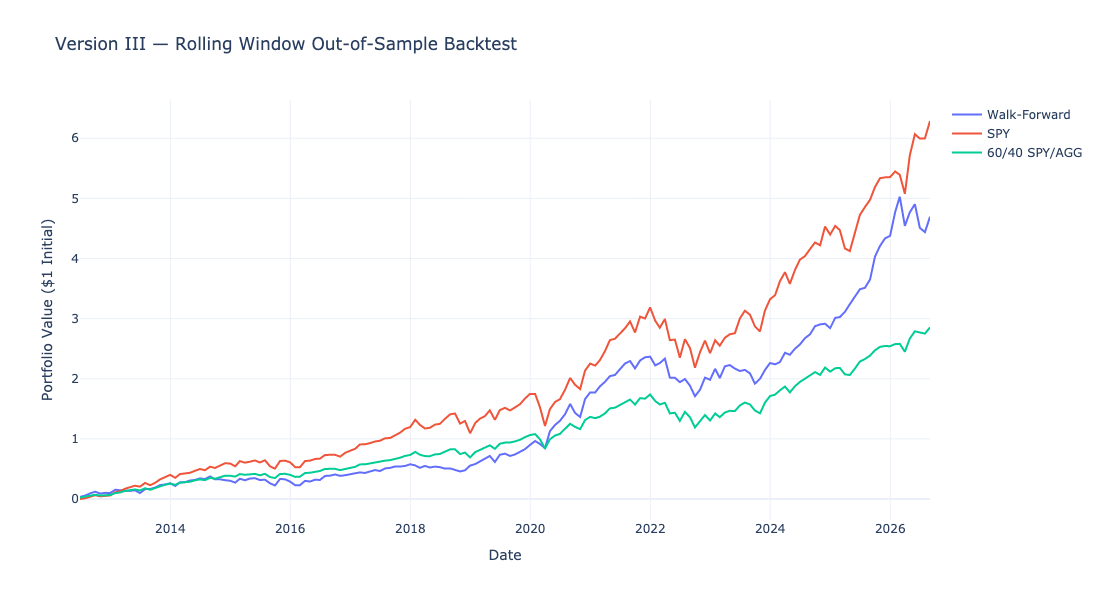

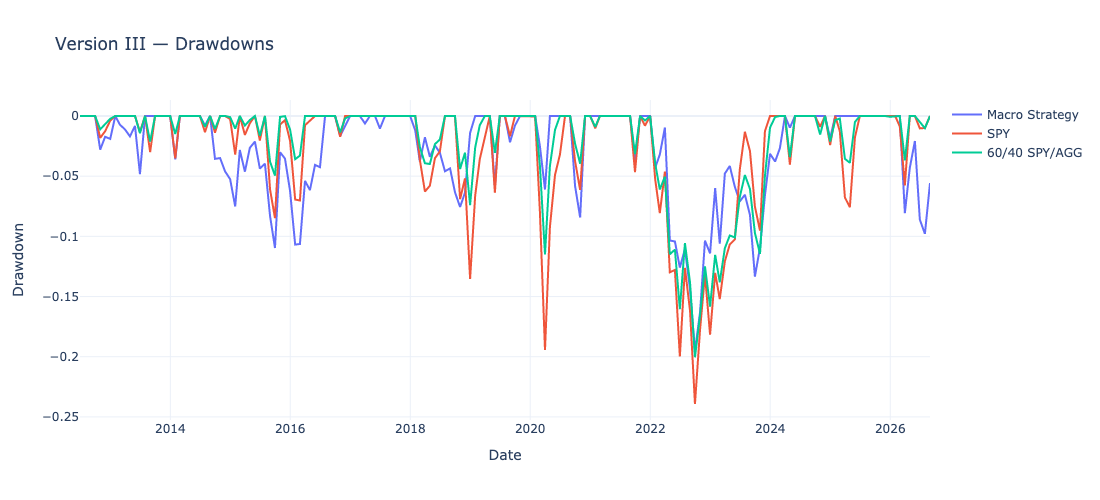

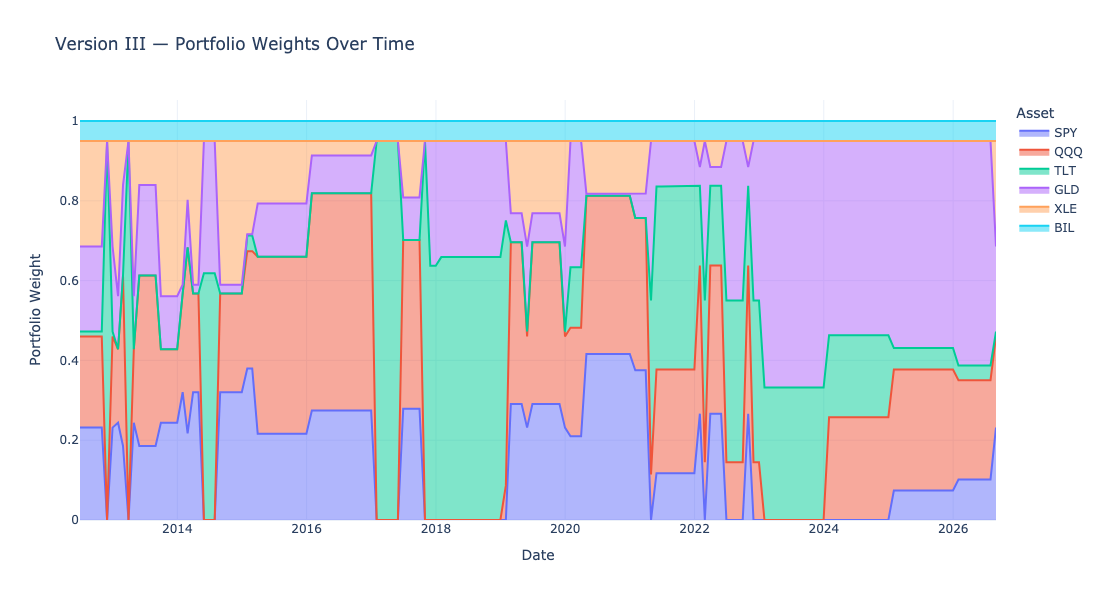

In [14]:
perf_v3 = pd.DataFrame([
    performance_summary(wf_portfolio_return_rolling, monthly_returns["BIL"], "Macro Strategy (Rolling Window)"),
    performance_summary(spy_eval_returns, monthly_returns["BIL"], "SPY Buy & Hold"),
])
print("\nPerformance Summary — Version III (Rolling Window):")
print(perf_v3.round(4))

regime_returns_v3 = pd.DataFrame(index=wf_portfolio_return_rolling.index)
regime_returns_v3["Strategy Return"] = wf_portfolio_return_rolling
regime_returns_v3["SPY_Return"] = spy_eval_returns
regime_returns_v3["regime"] = macro["regime"]

regime_perf_v3 = regime_returns_v3.groupby("regime")[["Strategy Return", "SPY_Return"]].apply(
    lambda g: g.apply(geo_annualize)
)
print("\nAnnualized Returns by Regime — Version III:")
print(regime_perf_v3)

fig = go.Figure()
fig.add_trace(go.Scatter(x=wf_cumulative_return_rolling.index, y=wf_cumulative_return_rolling, mode="lines", name="Walk-Forward"))
fig.add_trace(go.Scatter(x=spy_cumulative_return_wf.index, y=spy_cumulative_return_wf, mode="lines", name="SPY"))
fig.add_trace(go.Scatter(x=sixty_forty_cumulative_return.index, y=sixty_forty_cumulative_return, mode="lines", name="60/40 SPY/AGG"))
fig.update_layout(
    title="Version III — Rolling Window Out-of-Sample Backtest",
    xaxis_title="Date", yaxis_title="Portfolio Value ($1 Initial)",
    template="plotly_white", width=1100, height=600
)
fig.show(renderer="png")

dd_strategy_v3 = drawdown_series(wf_cumulative_return_rolling)
dd_spy_v3 = drawdown_series(spy_cumulative_return_wf)
dd_60_40_v3 = drawdown_series(sixty_forty_cumulative_return)

fig = go.Figure()
fig.add_trace(go.Scatter(x=dd_strategy_v3.index, y=dd_strategy_v3, mode="lines", name="Macro Strategy"))
fig.add_trace(go.Scatter(x=dd_spy_v3.index, y=dd_spy_v3, mode="lines", name="SPY"))
fig.add_trace(go.Scatter(x=dd_60_40_v3.index, y=dd_60_40_v3, mode="lines", name="60/40 SPY/AGG"))
fig.update_layout(
    title="Version III — Drawdowns",
    xaxis_title="Date", yaxis_title="Drawdown",
    template="plotly_white", width=1100, height=500
)
fig.show(renderer="png")

weights_long_v3 = test_weights_wf_rolling.reset_index(names="Date").melt(id_vars="Date", var_name="Asset", value_name="Weight")
fig = px.area(weights_long_v3, x="Date", y="Weight", color="Asset", title="Version III — Portfolio Weights Over Time")
fig.update_layout(template="plotly_white", width=1100, height=600, yaxis_title="Portfolio Weight")
fig.show(renderer="png")

In [15]:
fallback_count_v3 = sum(
    1 for date in eval_period.index
    if not (
        pd.notna(eval_period.loc[date, "regime"]) and
        eval_period.loc[date, "regime"] in get_weights_for_date(date, wf_weights_by_date_rolling).index
    )
)
print(f"{fallback_count_v3} of {len(eval_period)} dates used the fallback (Version III)")

9 of 171 dates used the fallback (Version III)


## Transaction Costs

Applied to Version III, the best-performing version. Turnover is the month-over-month change in *portfolio weights*, not in returns — that's what a rebalance actually trades.

In [16]:
cost_per_unit_turnover = 0.001  # 10bps per unit of monthly turnover

turnover = test_weights_wf_rolling.diff().abs().sum(axis=1)
cost_drag = turnover * cost_per_unit_turnover
portfolio_return_after_costs = wf_portfolio_return_rolling - cost_drag

perf_v3_after_costs = pd.DataFrame([
    performance_summary(portfolio_return_after_costs, monthly_returns["BIL"], "Macro Strategy (Rolling, After Costs)"),
])
print("\nPerformance Summary — Version III After Transaction Costs:")
print(perf_v3_after_costs.round(4))


Performance Summary — Version III After Transaction Costs:
                                Strategy  Volatility  Sharpe  Max Drawdown  \
0  Macro Strategy (Rolling, After Costs)      0.1202  0.9284       -0.1986   

   Total Return  
0        4.4835  


# Model Comparison

In [17]:
comparison = pd.DataFrame([
    performance_summary(portfolio_return, monthly_returns["BIL"], "V1: Static Weights"),
    performance_summary(wf_portfolio_return, monthly_returns["BIL"], "V2: Expanding Window"),
    performance_summary(wf_portfolio_return_rolling, monthly_returns["BIL"], "V3: Rolling Window"),
    performance_summary(portfolio_return_after_costs, monthly_returns["BIL"], "V3: Rolling Window (After Costs)"),
    performance_summary(spy_eval_returns, monthly_returns["BIL"], "SPY Buy & Hold"),
    performance_summary(sixty_forty_return.loc[eval_period.index[0]:], monthly_returns["BIL"], "60/40 SPY/AGG"),
])
print("Model Comparison — All Versions vs. SPY:")
print(comparison.round(4))

print("\nCorrelation with SPY:")
print(f"  V2 (Expanding): {wf_portfolio_return.corr(eval_period['SPY']):.3f}")
print(f"  V3 (Rolling):   {wf_portfolio_return_rolling.corr(eval_period['SPY']):.3f}")

Model Comparison — All Versions vs. SPY:
                           Strategy  Volatility  Sharpe  Max Drawdown  \
0                V1: Static Weights      0.1200  0.4630       -0.2634   
1              V2: Expanding Window      0.1222  0.8248       -0.3010   
2                V3: Rolling Window      0.1203  0.9500       -0.1954   
3  V3: Rolling Window (After Costs)      0.1202  0.9284       -0.1986   
4                    SPY Buy & Hold      0.1397  0.9624       -0.2393   
5                     60/40 SPY/AGG      0.0918  0.9119       -0.2005   

   Total Return  
0        2.2702  
1        3.6918  
2        4.6929  
3        4.4835  
4        6.2868  
5        2.8537  

Correlation with SPY:
  V2 (Expanding): 0.537
  V3 (Rolling):   0.722
